In [4]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import norm
from collections import namedtuple


## Assignment 9 - Part 2: Climate Change Trend Analysis
For precipitation, `pr` is converted from `kg m-2 s-1` to `mm/day`, then summed to annual total precipitation in `mm/year`.

In [5]:
# ----------------------------------------------------------
# TREND ANALYSIS FUNCTIONS (Hamed & Rao 1998 + Sen's Slope)
# ----------------------------------------------------------

def hamed_rao_mk_test(x, alpha=0.05):
    """Modified MK test with autocorrelation correction (Hamed & Rao 1998)."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    n = len(x)
    s = 0
    for k in range(n - 1):
        for j in range(k + 1, n):
            s += np.sign(x[j] - x[k])

    var_s = n * (n - 1) * (2 * n + 5) / 18
    ties = np.unique(x, return_counts=True)[1]
    for t in ties:
        var_s -= t * (t - 1) * (2 * t + 5) / 18

    if n > 10:
        acf = [1.0]
        for i in range(1, max(1, n // 4)):
            corr = np.corrcoef(x[:-i], x[i:])[0, 1]
            if np.isfinite(corr):
                acf.append(corr)
        denom = 1 + 2 * sum((n - i) / n * acf[i] for i in range(1, len(acf)))
        if denom > 0:
            n_eff = n / denom
            var_s *= n_eff / n

    if var_s <= 0:
        z = 0.0
    elif s > 0:
        z = (s - 1) / np.sqrt(var_s)
    elif s < 0:
        z = (s + 1) / np.sqrt(var_s)
    else:
        z = 0.0

    p = 2 * (1 - norm.cdf(abs(z)))
    h = abs(z) > norm.ppf(1 - alpha / 2)

    Trend = namedtuple('Trend', ['trend', 'h', 'p', 'z', 's'])
    trend = 'increasing' if s > 0 else 'decreasing' if s < 0 else 'no trend'
    return Trend(trend=trend, h=bool(h), p=float(p), z=float(z), s=int(s))

def sens_slope(x, y):
    """Sen's slope estimator."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    slopes = []
    for i in range(len(x)):
        for j in range(i + 1, len(x)):
            slopes.append((y[j] - y[i]) / (x[j] - x[i]))
    return float(np.median(slopes))


In [6]:
BASE_DIR = r"D:\\KAUST\\semster2\\geo_env_modelling\\assignment9\\OneDrive_1_2026-4-10"

SCENARIOS = {
    'SSP126': {
        'temp': BASE_DIR + r'\\SSP126\\Temp_126\\Temp126.nc',
        'pr': BASE_DIR + r'\\SSP126\\Precipitation_126\\PR_126.nc',
    },
    'SSP370': {
        'temp': BASE_DIR + r'\\SSP370\\Temp_370\\Temp_370.nc',
        'pr': BASE_DIR + r'\\SSP370\\Precipitation_370\\pr370.nc',
    },
}

def annual_temperature_series(path):
    ds = xr.open_dataset(path)
    weights = xr.DataArray(
        np.cos(np.deg2rad(ds.lat.values)),
        coords={'lat': ds.lat},
        dims=('lat',),
    )
    annual = (
        (ds['tas'] - 273.15)
        .weighted(weights)
        .mean(('lat', 'lon'))
        .resample(time='YS')
        .mean()
    )
    df = annual.to_dataframe(name='temperature_c').reset_index()
    df['year'] = df['time'].dt.year
    ds.close()
    return df[['year', 'temperature_c']]

def annual_precip_series(path):
    ds = xr.open_dataset(path)
    weights = xr.DataArray(
        np.cos(np.deg2rad(ds.lat.values)),
        coords={'lat': ds.lat},
        dims=('lat',),
    )
    annual = (
        (ds['pr'] * 86400.0)
        .weighted(weights)
        .mean(('lat', 'lon'))
        .resample(time='YS')
        .sum()
    )
    df = annual.to_dataframe(name='precip_mm_year').reset_index()
    df['year'] = df['time'].dt.year
    ds.close()
    return df[['year', 'precip_mm_year']]

results = {}

for scenario, paths in SCENARIOS.items():
    temp_df = annual_temperature_series(paths['temp'])
    precip_df = annual_precip_series(paths['pr'])

    temp_mk = hamed_rao_mk_test(temp_df['temperature_c'])
    precip_mk = hamed_rao_mk_test(precip_df['precip_mm_year'])

    results[scenario] = {
        'temperature': {
            'data': temp_df,
            'mk': temp_mk,
            'sen': sens_slope(temp_df['year'], temp_df['temperature_c']),
        },
        'precipitation': {
            'data': precip_df,
            'mk': precip_mk,
            'sen': sens_slope(precip_df['year'], precip_df['precip_mm_year']),
        },
    }

results


{'SSP126': {'temperature': {'data':     year  temperature_c
   0   2015      25.161564
   1   2016      25.393345
   2   2017      25.323109
   3   2018      25.426095
   4   2019      25.573503
   ..   ...            ...
   81  2096      25.543286
   82  2097      25.924026
   83  2098      26.093162
   84  2099      25.908375
   85  2100      26.318080
   
   [86 rows x 2 columns],
   'mk': Trend(trend='increasing', h=True, p=0.0, z=10.737719635246467, s=921),
   'sen': 0.00443076183004347},
  'precipitation': {'data':     year  precip_mm_year
   0   2015      130.085599
   1   2016       80.931424
   2   2017      121.587901
   3   2018       68.354433
   4   2019      136.445740
   ..   ...             ...
   81  2096       63.827127
   82  2097      163.650451
   83  2098       90.781894
   84  2099       94.796749
   85  2100      105.535435
   
   [86 rows x 2 columns],
   'mk': Trend(trend='decreasing', h=False, p=0.5067566418876086, z=-0.6638963666368843, s=-233),
   'sen': -0

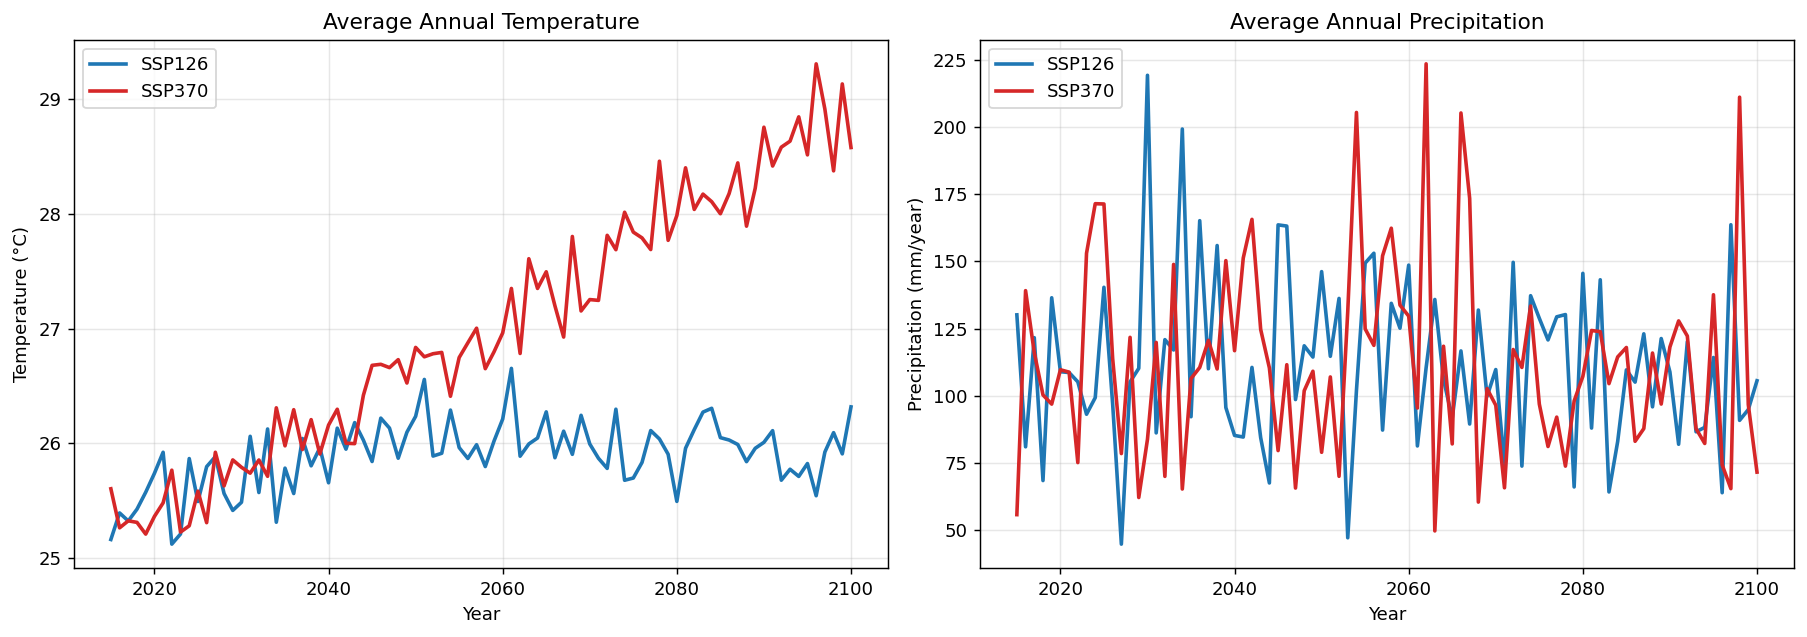

In [7]:
colors = {'SSP126': '#1f77b4', 'SSP370': '#d62728'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=130)

for scenario in ['SSP126', 'SSP370']:
    temp_df = results[scenario]['temperature']['data']
    precip_df = results[scenario]['precipitation']['data']
    axes[0].plot(temp_df['year'], temp_df['temperature_c'], label=scenario, color=colors[scenario], linewidth=2)
    axes[1].plot(precip_df['year'], precip_df['precip_mm_year'], label=scenario, color=colors[scenario], linewidth=2)

axes[0].set_title('Average Annual Temperature')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Temperature (°C)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title('Average Annual Precipitation')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Precipitation (mm/year)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


In [8]:
import xarray as xr
import numpy as np
import os
def calculate_wet_bulb_temperature(temp_k, rh_percent):
    
    temp_c = temp_k - 273.15
    
   
    wbt_c = temp_c * np.arctan(0.151977 * (rh_percent + 8.313659)**0.5) + \
            np.arctan(temp_c + rh_percent) - np.arctan(rh_percent - 1.676331) + \
            0.00391838 * (rh_percent)**(3/2) * np.arctan(0.023101 * rh_percent) - 4.686035
    
    
    wbt_k = wbt_c + 273.15
    
    return wbt_k

def main():
    
    temp_file = r"D:\\KAUST\\semster2\\geo_env_modelling\\assignment9\\OneDrive_1_2026-4-10\\SSP370\\Temp_370\\Temp_370.nc"
    rh_file = r"D:\\KAUST\\semster2\\geo_env_modelling\\assignment9\\OneDrive_1_2026-4-10\\SSP370\\Humudity_370\\RH370.nc"
    
    
    output_dir = r"D:\\KAUST\\semster2\\geo_env_modelling\\assignment9\\wet_bulb_output"
    output_file = os.path.join(output_dir, "wb_370.nc")
    
    
    os.makedirs(output_dir, exist_ok=True)
    
    
    ds_temp = xr.open_dataset(temp_file)
    ds_rh = xr.open_dataset(rh_file)
    
    
    temp_k = ds_temp['tas'] 
    rh_percent = ds_rh['hurs']  
    
    
    wbt_k = calculate_wet_bulb_temperature(temp_k, rh_percent)
    
    
    ds_output = xr.Dataset(
        {
            'wet_bulb_temp': (['time', 'lat', 'lon'], wbt_k.values),
        },
        coords={
            'time': ds_temp['time'],
            'lat': ds_temp['lat'],
            'lon': ds_temp['lon'],
        },
        attrs={
            'description': 'Wet bulb temperature calculated from temperature and relative humidity',
            'units': 'K',
            'calculation_method': "Stull's method (2011)",
        }
    )
    
    
    ds_output.to_netcdf(output_file)
    print(f"Wet bulb temperature saved to: {output_file}")
    
    
    ds_temp.close()
    ds_rh.close()

if __name__ == "__main__":
    main()








Wet bulb temperature saved to: D:\\KAUST\\semster2\\geo_env_modelling\\assignment9\\wet_bulb_output\wb_370.nc


## Part 3 - Analysis of Climate Extremes

For this part, I use the daily spatial mean over the provided Saudi study-region grid, then take the annual maximum of that daily regional mean.

In [9]:
def lat_weights_from_path(path):
    ds = xr.open_dataset(path)
    weights = xr.DataArray(
        np.cos(np.deg2rad(ds.lat.values)),
        coords={'lat': ds.lat},
        dims=('lat',),
    )
    ds.close()
    return weights

def annual_mean_and_max_from_daily(data_array, weights):
    daily_region_mean = data_array.weighted(weights).mean(('lat', 'lon'))
    annual_mean = daily_region_mean.resample(time='YS').mean()
    annual_max = daily_region_mean.resample(time='YS').max()
    years = annual_mean.time.dt.year.values.astype(int)
    return years, annual_mean.values.astype(float), annual_max.values.astype(float)

PART3_BASE_DIR = r"D:\\KAUST\\semster2\\geo_env_modelling\\assignment9\\OneDrive_1_2026-4-10"

PART3_SCENARIOS = {
    'SSP126': {
        'temp': PART3_BASE_DIR + r'\\SSP126\\Temp_126\\Temp126.nc',
        'pr': PART3_BASE_DIR + r'\\SSP126\\Precipitation_126\\PR_126.nc',
    },
    'SSP370': {
        'temp': PART3_BASE_DIR + r'\\SSP370\\Temp_370\\Temp_370.nc',
        'pr': PART3_BASE_DIR + r'\\SSP370\\Precipitation_370\\pr370.nc',
    },
}

part3_results = {}

for scenario, paths in PART3_SCENARIOS.items():
    ds_temp = xr.open_dataset(paths['temp'])
    ds_pr = xr.open_dataset(paths['pr'])
    weights = xr.DataArray(
        np.cos(np.deg2rad(ds_temp.lat.values)),
        coords={'lat': ds_temp.lat},
        dims=('lat',),
    )

    years, _, temp_max = annual_mean_and_max_from_daily(ds_temp['tas'] - 273.15, weights)
    _, _, pr_max = annual_mean_and_max_from_daily(ds_pr['pr'] * 86400.0, weights)

    part3_results[scenario] = {
        'years': years,
        'temperature_max_c': temp_max,
        'precipitation_max_mm_day': pr_max,
        'temperature_mk': hamed_rao_mk_test(temp_max),
        'temperature_sen': sens_slope(years, temp_max),
        'precipitation_mk': hamed_rao_mk_test(pr_max),
        'precipitation_sen': sens_slope(years, pr_max),
    }

    ds_temp.close()
    ds_pr.close()

part3_results


{'SSP126': {'years': array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025,
         2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036,
         2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047,
         2048, 2049, 2050, 2051, 2052, 2053, 2054, 2055, 2056, 2057, 2058,
         2059, 2060, 2061, 2062, 2063, 2064, 2065, 2066, 2067, 2068, 2069,
         2070, 2071, 2072, 2073, 2074, 2075, 2076, 2077, 2078, 2079, 2080,
         2081, 2082, 2083, 2084, 2085, 2086, 2087, 2088, 2089, 2090, 2091,
         2092, 2093, 2094, 2095, 2096, 2097, 2098, 2099, 2100]),
  'temperature_max_c': array([32.22663673, 32.85169794, 33.38204069, 32.83017744, 32.83957355,
         33.73788953, 33.72361775, 32.87667997, 32.77183081, 33.43629315,
         33.24138729, 33.44753315, 33.14512592, 33.15751279, 33.49146778,
         33.44660504, 33.33227542, 33.07560391, 34.02998821, 33.89329431,
         33.34274801, 34.08254263, 33.98295972, 33.2292061 , 33.4760958 ,


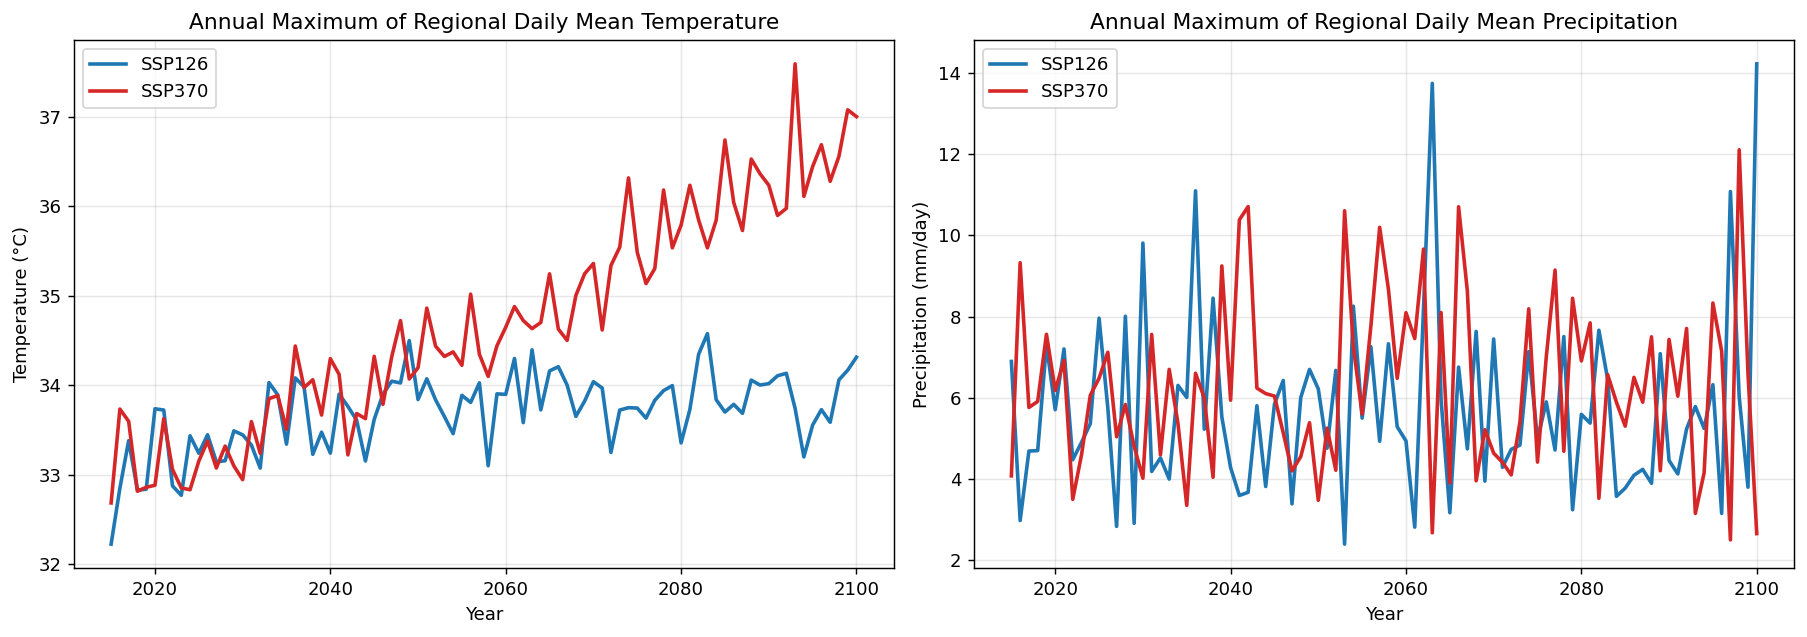

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=130)

for scenario in ['SSP126', 'SSP370']:
    axes[0].plot(
        part3_results[scenario]['years'],
        part3_results[scenario]['temperature_max_c'],
        label=scenario,
        color=colors[scenario],
        linewidth=2,
    )
    axes[1].plot(
        part3_results[scenario]['years'],
        part3_results[scenario]['precipitation_max_mm_day'],
        label=scenario,
        color=colors[scenario],
        linewidth=2,
    )

axes[0].set_title('Annual Maximum of Regional Daily Mean Temperature')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Temperature (°C)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title('Annual Maximum of Regional Daily Mean Precipitation')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Precipitation (mm/day)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()


## Part 4 - Wet Bulb Temperature Calculation


In [11]:
from pathlib import Path

WET_BULB_DIR = Path('wet_bulb_output')
WET_BULB_DIR.mkdir(exist_ok=True)

WET_BULB_PATHS = {
    'SSP126': WET_BULB_DIR / 'wb_126.nc',
    'SSP370': WET_BULB_DIR / 'wb_370.nc',
}

RH_PATHS = {
    'SSP126': BASE_DIR + r'\\SSP126\\Humidity_126\\RH126.nc',
    'SSP370': BASE_DIR + r'\\SSP370\\Humudity_370\\RH370.nc',
}

def ensure_wet_bulb_file(scenario):
    output_file = WET_BULB_PATHS[scenario]
    if output_file.exists():
        return output_file

    ds_temp = xr.open_dataset(SCENARIOS[scenario]['temp'])
    ds_rh = xr.open_dataset(RH_PATHS[scenario])
    wbt_k = calculate_wet_bulb_temperature(ds_temp['tas'], ds_rh['hurs']).astype('float32')

    ds_output = xr.Dataset(
        {
            'wet_bulb_temp': (['time', 'lat', 'lon'], wbt_k.values),
        },
        coords={
            'time': ds_temp['time'],
            'lat': ds_temp['lat'],
            'lon': ds_temp['lon'],
        },
        attrs={
            'description': f'Wet bulb temperature for {scenario}',
            'units': 'K',
            'calculation_method': "Stull's method (2011)",
        }
    )

    ds_output.to_netcdf(output_file)
    ds_temp.close()
    ds_rh.close()
    return output_file

for scenario in ['SSP126', 'SSP370']:
    print(scenario, ensure_wet_bulb_file(scenario))


SSP126 wet_bulb_output\wb_126.nc
SSP370 wet_bulb_output\wb_370.nc


In [12]:
part4_results = {}

for scenario in ['SSP126', 'SSP370']:
    ds_temp = xr.open_dataset(SCENARIOS[scenario]['temp'])
    ds_wb = xr.open_dataset(WET_BULB_PATHS[scenario])
    weights = xr.DataArray(
        np.cos(np.deg2rad(ds_temp.lat.values)),
        coords={'lat': ds_temp.lat},
        dims=('lat',),
    )

    years, wb_mean, wb_max = annual_mean_and_max_from_daily(ds_wb['wet_bulb_temp'] - 273.15, weights)

    part4_results[scenario] = {
        'years': years,
        'wet_bulb_mean_c': wb_mean,
        'wet_bulb_max_c': wb_max,
        'wet_bulb_mean_sen': sens_slope(years, wb_mean),
    }

    ds_temp.close()
    ds_wb.close()

part4_results


{'SSP126': {'years': array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025,
         2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036,
         2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047,
         2048, 2049, 2050, 2051, 2052, 2053, 2054, 2055, 2056, 2057, 2058,
         2059, 2060, 2061, 2062, 2063, 2064, 2065, 2066, 2067, 2068, 2069,
         2070, 2071, 2072, 2073, 2074, 2075, 2076, 2077, 2078, 2079, 2080,
         2081, 2082, 2083, 2084, 2085, 2086, 2087, 2088, 2089, 2090, 2091,
         2092, 2093, 2094, 2095, 2096, 2097, 2098, 2099, 2100]),
  'wet_bulb_mean_c': array([16.39451091, 16.50730108, 16.8973816 , 16.16058325, 16.69934203,
         16.8759278 , 16.97280161, 16.39335261, 16.44922681, 16.77861058,
         16.68076373, 16.77427177, 16.46065445, 16.61692712, 16.74939162,
         17.25646717, 16.87020724, 16.73237886, 17.39882406, 16.88090874,
         16.60894234, 17.00238118, 17.08471362, 16.94940429, 16.84697057,
  

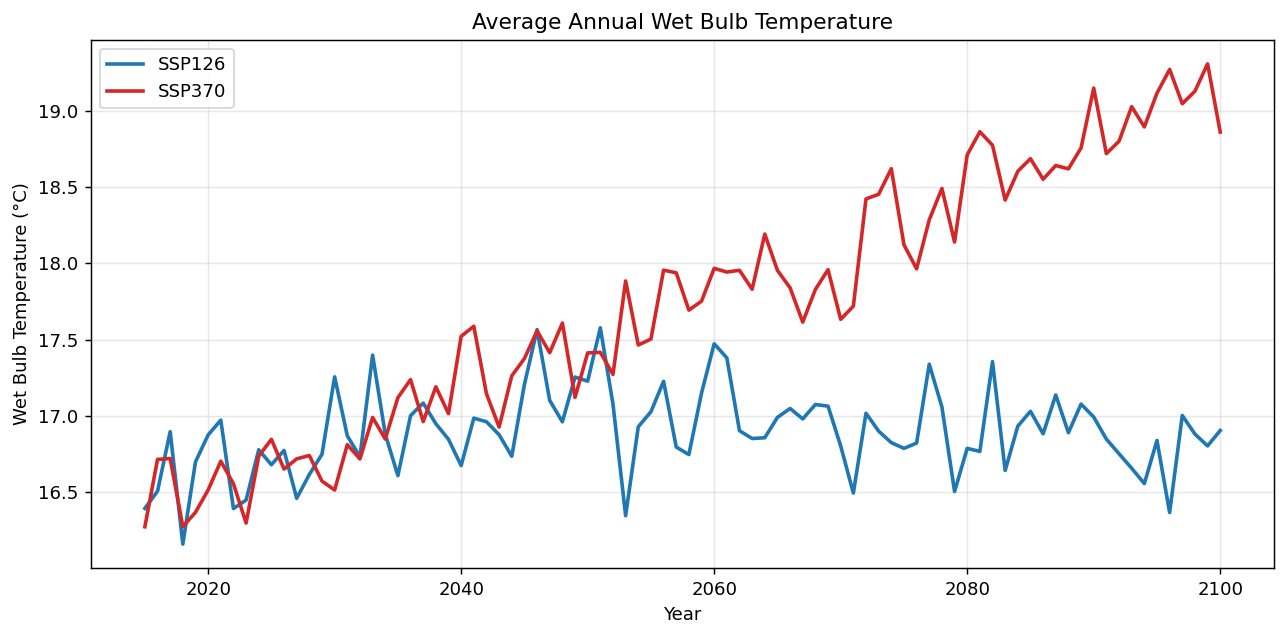

In [13]:
plt.figure(figsize=(10, 5), dpi=130)

for scenario in ['SSP126', 'SSP370']:
    plt.plot(
        part4_results[scenario]['years'],
        part4_results[scenario]['wet_bulb_mean_c'],
        label=scenario,
        color=colors[scenario],
        linewidth=2,
    )

plt.title('Average Annual Wet Bulb Temperature')
plt.xlabel('Year')
plt.ylabel('Wet Bulb Temperature (°C)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## Part 5 - Wet Bulb Temperature Trend Analysis and Extremes

In [14]:
part5_results = {}

for scenario in ['SSP126', 'SSP370']:
    years = part4_results[scenario]['years']
    wb_mean = part4_results[scenario]['wet_bulb_mean_c']
    wb_max = part4_results[scenario]['wet_bulb_max_c']

    part5_results[scenario] = {
        'years': years,
        'wet_bulb_mean_c': wb_mean,
        'wet_bulb_max_c': wb_max,
        'wet_bulb_mean_mk': hamed_rao_mk_test(wb_mean),
        'wet_bulb_mean_sen': sens_slope(years, wb_mean),
        'wet_bulb_max_mk': hamed_rao_mk_test(wb_max),
        'wet_bulb_max_sen': sens_slope(years, wb_max),
    }

part5_results


{'SSP126': {'years': array([2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025,
         2026, 2027, 2028, 2029, 2030, 2031, 2032, 2033, 2034, 2035, 2036,
         2037, 2038, 2039, 2040, 2041, 2042, 2043, 2044, 2045, 2046, 2047,
         2048, 2049, 2050, 2051, 2052, 2053, 2054, 2055, 2056, 2057, 2058,
         2059, 2060, 2061, 2062, 2063, 2064, 2065, 2066, 2067, 2068, 2069,
         2070, 2071, 2072, 2073, 2074, 2075, 2076, 2077, 2078, 2079, 2080,
         2081, 2082, 2083, 2084, 2085, 2086, 2087, 2088, 2089, 2090, 2091,
         2092, 2093, 2094, 2095, 2096, 2097, 2098, 2099, 2100]),
  'wet_bulb_mean_c': array([16.39451091, 16.50730108, 16.8973816 , 16.16058325, 16.69934203,
         16.8759278 , 16.97280161, 16.39335261, 16.44922681, 16.77861058,
         16.68076373, 16.77427177, 16.46065445, 16.61692712, 16.74939162,
         17.25646717, 16.87020724, 16.73237886, 17.39882406, 16.88090874,
         16.60894234, 17.00238118, 17.08471362, 16.94940429, 16.84697057,
  

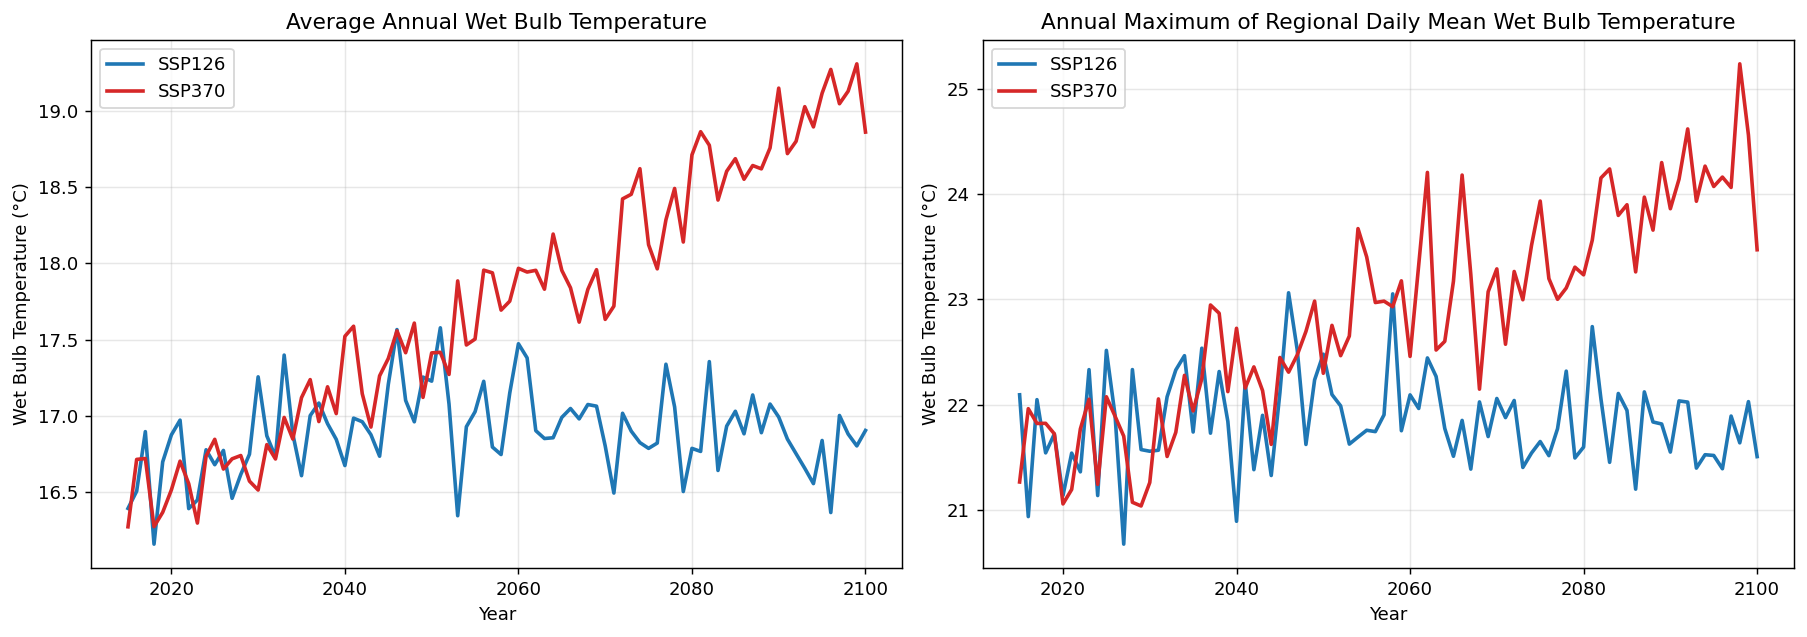

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=130)

for scenario in ['SSP126', 'SSP370']:
    axes[0].plot(
        part5_results[scenario]['years'],
        part5_results[scenario]['wet_bulb_mean_c'],
        label=scenario,
        color=colors[scenario],
        linewidth=2,
    )
    axes[1].plot(
        part5_results[scenario]['years'],
        part5_results[scenario]['wet_bulb_max_c'],
        label=scenario,
        color=colors[scenario],
        linewidth=2,
    )

axes[0].set_title('Average Annual Wet Bulb Temperature')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Wet Bulb Temperature (°C)')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].set_title('Annual Maximum of Regional Daily Mean Wet Bulb Temperature')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Wet Bulb Temperature (°C)')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()
